# Classification Problem


## HR - Attrition Analytics

Human Resources are critical resources of any organiazation. Organizations spend huge amount of time and money to hire and nuture their employees. It is a huge loss for companies if employees leave, especially the key resources. So if HR can predict weather employees are at risk for leaving the company, it will allow them to identify the attrition risks and help understand and provie necessary support to retain those employees or do preventive hiring to minimize the impact to the orgranization.

## Data Set

This dataset is taken from kaggle https://www.kaggle.com/datasets/jacksonchou/hr-data-for-analytics


### Dependent variable

Left : 0 if employee did not leave , 1 if left company

### Independent variables

- **satisfaction_level** : means how much employee satisfied (0 less satisfied , 1 most satisfied)
- **last_evaluation** : means employees' evaluation for last month (0 bad , 1 Excellent)
- **number_project** : number of projects the employee worked on
- **average_montly_hours** : average months employee spends at work per month
- **time_spend_company** : years the employee spent in a company
- **Work_accident** : 0 if he did not have an accident , 1 if had at least one
- **promotion_last_5years** : 0 if he did not have any promotion in last 5 years , 1 if had at least one
- **dept** : department in which employee works
- **salary** : High, medium or low bracket

## Loading Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
#uncomment this code for google colab
#from google.colab import files
#uploaded = files.upload()

In [6]:
hr_df = pd.read_csv('HR_Data.csv')

In [8]:
#View some records from dataset 
hr_df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [10]:
#Check dataset information 
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [14]:
#Check dataset information 
hr_df.shape

(14999, 10)

## EDA

**Question 1**: How satisfcation level influences employee's decision to leave?

In [22]:
# Calculate correlation
hr_df[['satisfaction_level','left']].corr()

#Is it making sense?

,satisfaction_level,left
satisfaction_level,1.000000,-0.388375
left,-0.388375,1.000000


<Axes: xlabel='satisfaction_level', ylabel='Count'>

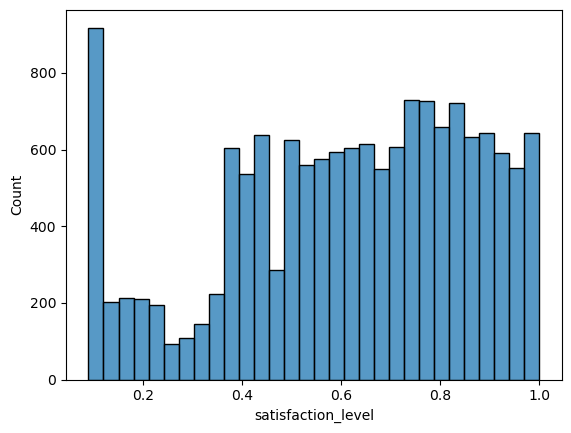

In [24]:
sn.histplot(data=hr_df, x='satisfaction_level')

<Axes: xlabel='satisfaction_level', ylabel='Count'>

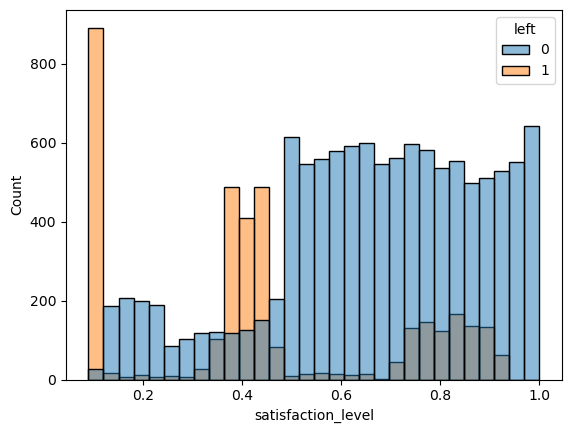

In [26]:
sn.histplot(data=hr_df, x='satisfaction_level', hue = 'left')

**Question 2**: How time spend in the company influences employee's decision to leave? 

In [35]:
## Class suggestion
pd.crosstab(hr_df.time_spend_company,
            hr_df.left, 
            normalize = 'index') * 100

left,0,1
time_spend_company,,
2,98.366215,1.633785
3,75.384138,24.615862
4,65.193586,34.806414
5,43.448744,56.551256
6,70.891365,29.108635
7,100.000000,0.000000
8,100.000000,0.000000
10,100.000000,0.000000


<Axes: xlabel='time_spend_company', ylabel='count'>

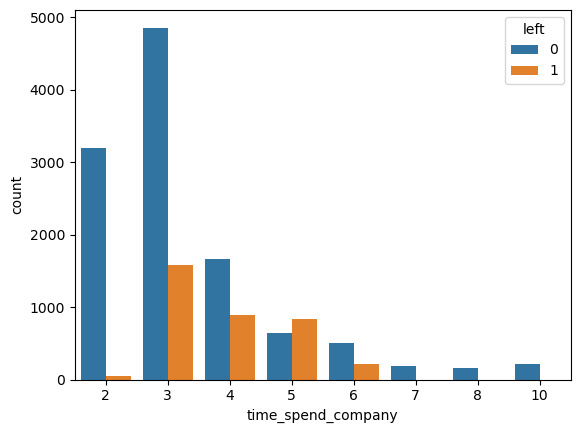

In [37]:
sn.countplot(x='time_spend_company', hue='left', data=hr_df)

<Axes: xlabel='average_montly_hours', ylabel='Count'>

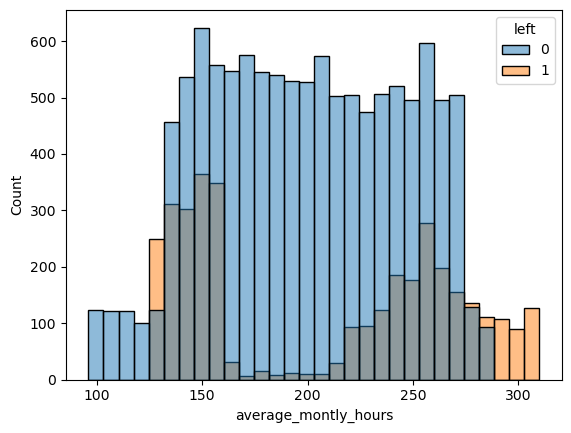

In [184]:
sn.histplot(data=hr_df, x='average_montly_hours', hue = 'left')

**Question 3**: Attrition patterns across different departments.

In [51]:
hr_df['dept'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

<Axes: xlabel='dept', ylabel='count'>

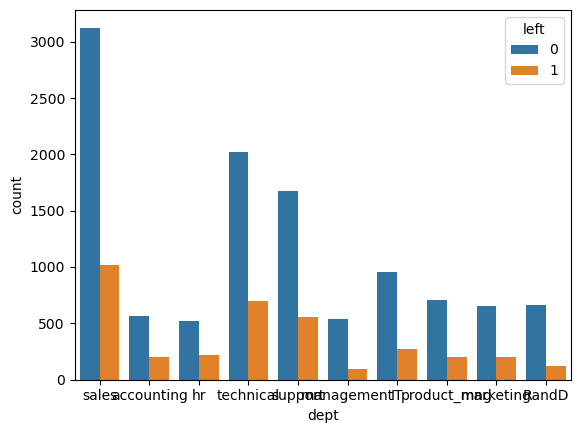

In [45]:
sn.countplot(x='dept', hue='left', data=hr_df)

In [47]:
## Class suggestion
pd.crosstab(hr_df.dept,
            hr_df.left, 
            normalize = 'index') * 100

left,0,1
dept,,
IT,77.750611,22.249389
RandD,84.625159,15.374841
accounting,73.402868,26.597132
hr,70.906631,29.093369
management,85.555556,14.444444
marketing,76.340326,23.659674
product_mng,78.048780,21.951220
sales,75.507246,24.492754
support,75.100942,24.899058


**Question 4:** How last evaluation influences employee's decision to leave?

<Axes: xlabel='last_evaluation', ylabel='Count'>

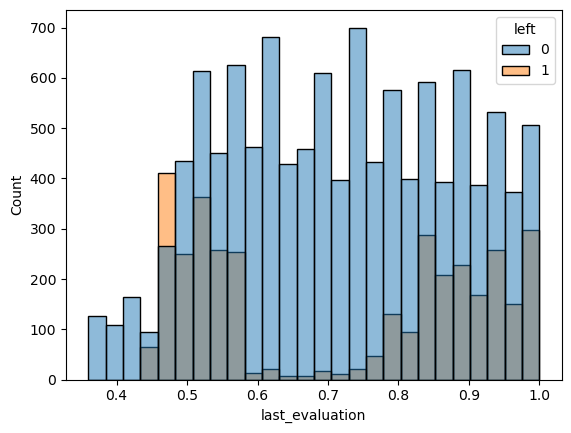

In [53]:
sn.histplot(data=hr_df, x='last_evaluation', hue = 'left')

## Building a Classification Model

First we will build a model with *satisfaction level* with *left*.

### Setting X and y Values

In [57]:
X = hr_df[['satisfaction_level']]
y = hr_df.left

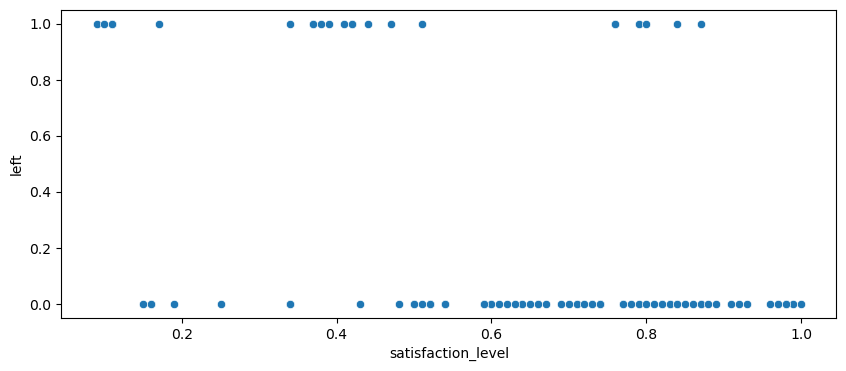

In [59]:
plt.figure(figsize=(10, 4))
sn.scatterplot(data = hr_df.sample(100, random_state = 78),
               x = 'satisfaction_level',
               y = 'left');

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [61]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split( X, y, 
                                                    test_size = 0.2, random_state = 100 )

In [73]:
#Check shape of Xtrain and Xtest
X_train.shape

(11999, 1)

In [71]:
X_test.shape

(3000, 1)

### Build Logistic Regression Model

In [75]:
from sklearn.linear_model import LogisticRegression

In [77]:
logreg_v1 = LogisticRegression(random_state=100)

In [79]:
logreg_v1.fit( X_train, y_train )

LogisticRegression(random_state=100)

### Finding Parameters

In [82]:
logreg_v1.intercept_

array([0.90010582])

In [84]:
logreg_v1.coef_

array([[-3.71760949]])

**Note:** What is the meaning of negative coefficient here?

### Probability of leaving at different Satisfaction Scores

- Create a list satisfaction scores from 0.0 to 1.0

In [88]:
sl_list = np.arange(0.0, 1.0, 0.05)

In [90]:
sl_list

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95])

In [92]:
beta_0 = logreg_v1.intercept_[0]
beta_1 = logreg_v1.coef_[0][0]

In [94]:
beta_0, beta_1

(0.9001058167516859, -3.7176094861183424)

- Calculate the probability values based on the logistic function

In [97]:
sl_probs = [(1.0 / (1.0 + np.exp(-(beta_0+beta_1*x)))) for x in sl_list]

In [99]:
sl_probs_df = pd.DataFrame({'SL': sl_list, 'Prob_Left': sl_probs })

In [101]:
sl_probs_df

,SL,Prob_Left
0,0.00,0.710971
1,0.05,0.671334
2,0.10,0.629097
3,0.15,0.584789
4,0.20,0.539066
5,0.25,0.492676
6,0.30,0.446412
7,0.35,0.401058
8,0.40,0.357338
9,0.45,0.315870


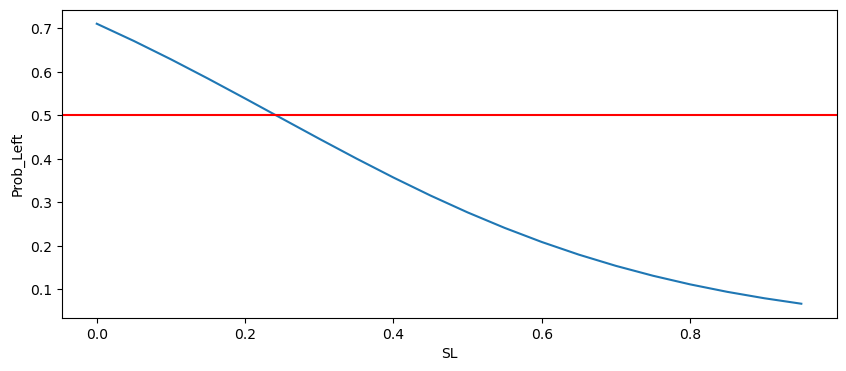

In [103]:
plt.figure(figsize=(10, 4))
sn.lineplot(data=sl_probs_df, x="SL", y="Prob_Left");
plt.axhline(y=0.5, color = 'r');

### Predicting on Test Data

In [105]:
y_pred = logreg_v1.predict(X_test)

In [107]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [109]:
y_df.sample(10, random_state=20)

,actual,predicted
310,1,1
14670,1,0
1322,1,0
3314,0,0
11348,0,1
12630,1,1
7293,0,0
13600,0,1
4038,0,0
1499,1,0


### Measuring Accuracy

In [111]:
from sklearn.metrics import accuracy_score

In [113]:
accuracy_score(y_test, y_pred)

0.7683333333333333

###  Exercise:

- Build a logistic regression model between average_montly_hours and left
- Predict probability for different values of average_montly_hours from 50 hours to 400 hours with 10 hours of step
- Plot the logistic function

In [115]:
X = hr_df[['average_montly_hours']]
y = hr_df.left

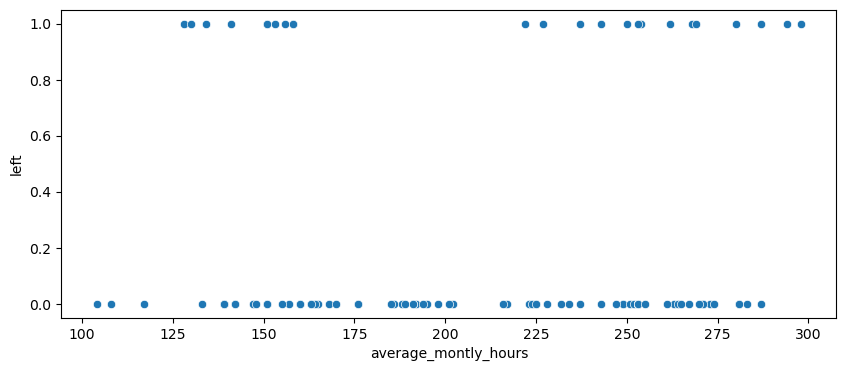

In [117]:
plt.figure(figsize=(10, 4))
sn.scatterplot(data = hr_df.sample(100, random_state = 78),
               x = 'average_montly_hours',
               y = 'left');

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [119]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split( X, y, 
                                                    test_size = 0.2, random_state = 100 )

In [123]:
#Check shape of Xtrain and Xtest
X_train.shape

(11999, 1)

In [125]:
X_test.shape

(3000, 1)

### Build Logistic Regression Model

In [128]:
from sklearn.linear_model import LogisticRegression

In [130]:
logreg_v1 = LogisticRegression(random_state=100)

In [132]:
logreg_v1.fit( X_train, y_train )

LogisticRegression(random_state=100)

### Finding Parameters

In [135]:
logreg_v1.intercept_

array([-1.89537826])

In [137]:
logreg_v1.coef_

array([[0.00351697]])

**Note:** What is the meaning of negative coefficient here?

### Probability of leaving at different Satisfaction Scores

- Create a list satisfaction scores from 0.0 to 1.0

In [154]:
sl_list = np.arange(50, 401, 10)

In [156]:
sl_list

array([ 50,  60,  70,  80,  90, 100, 110, 120, 130, 140, 150, 160, 170,
       180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300,
       310, 320, 330, 340, 350, 360, 370, 380, 390, 400])

In [158]:
beta_0 = logreg_v1.intercept_[0]
beta_1 = logreg_v1.coef_[0][0]

In [160]:
beta_0, beta_1

(-1.895378259128909, 0.003516972669478154)

- Calculate the probability values based on the logistic function

In [163]:
sl_probs = [(1.0 / (1.0 + np.exp(-(beta_0+beta_1*x)))) for x in sl_list]

In [165]:
sl_probs_df = pd.DataFrame({'SL': sl_list, 'Prob_Left': sl_probs })

In [167]:
sl_probs_df

,SL,Prob_Left
0,50,0.151932
1,60,0.156519
2,70,0.161218
3,80,0.166031
4,90,0.170958
5,100,0.176001
6,110,0.181160
7,120,0.186435
8,130,0.191829
9,140,0.197340


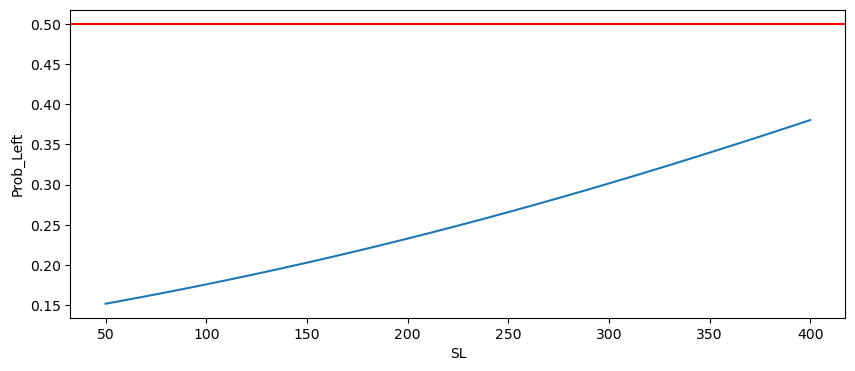

In [172]:
plt.figure(figsize=(10, 4))
sn.lineplot(data=sl_probs_df, x="SL", y="Prob_Left");
plt.axhline(y=0.5, color = 'r');

### Predicting on Test Data

In [174]:
y_pred = logreg_v1.predict(X_test)

In [176]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [178]:
y_df.sample(10, random_state=20)

,actual,predicted
310,1,0
14670,1,0
1322,1,0
3314,0,0
11348,0,0
12630,1,0
7293,0,0
13600,0,0
4038,0,0
1499,1,0


### Measuring Accuracy

In [180]:
from sklearn.metrics import accuracy_score

In [182]:
accuracy_score(y_test, y_pred)

0.75

### Exercise:

- Build a logistic regression model with all the variables and left
- Compute RoC AUC and draw the curve
- Compute confusion and draw the confusion matrix

In [191]:
X = hr_df[['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 
           'time_spend_company', 'Work_accident', 'promotion_last_5years', 'dept', 'salary']]
y = hr_df.left

In [282]:
X = list(hr_df.columns)
X.remove('left')

In [284]:
encoded_hr_df = pd.get_dummies(hr_df[X],columns=['dept','salary'])

In [286]:
X = encoded_hr_df
y = hr_df['left']

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [289]:
from sklearn.model_selection import train_test_split

In [291]:
X_train, X_test, y_train, y_test = train_test_split( X, y, 
                                                    test_size = 0.2, random_state = 100 )

In [293]:
#Check shape of Xtrain and Xtest
X_train.shape

(11999, 20)

In [295]:
X_test.shape

(3000, 20)

### Build Logistic Regression Model

In [298]:
from sklearn.linear_model import LogisticRegression

In [300]:
logreg_v1 = LogisticRegression(random_state=100)

In [302]:
logreg_v1.fit( X_train, y_train )

LogisticRegression(random_state=100)

### Finding Parameters

In [305]:
logreg_v1.intercept_

array([-0.48145925])

In [307]:
logreg_v1.coef_

array([[-3.68690295,  0.04752757, -0.2496412 ,  0.00493677,  0.2726062 ,
        -1.65462296, -0.55942091, -0.13827465, -0.48305154,  0.10523067,
         0.30163169, -0.50415355, -0.04952515, -0.13103249,  0.12368883,
         0.14140871,  0.16344887, -1.4112555 ,  0.7263699 ,  0.214257  ]])

### Predicting on Test Data

In [309]:
y_pred = logreg_v1.predict(X_test)

In [311]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [313]:
y_df.sample(10, random_state=20)

,actual,predicted
310,1,1
14670,1,0
1322,1,0
3314,0,0
11348,0,0
12630,1,1
7293,0,0
13600,0,0
4038,0,0
1499,1,0


### Measuring Accuracy

In [316]:
from sklearn.metrics import accuracy_score

In [318]:
accuracy_score(y_test, y_pred)

0.7843333333333333

In [320]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [322]:
cm = confusion_matrix(y_df.actual, y_df.predicted, labels=[1,0])

In [324]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['Left', 'No Left'])

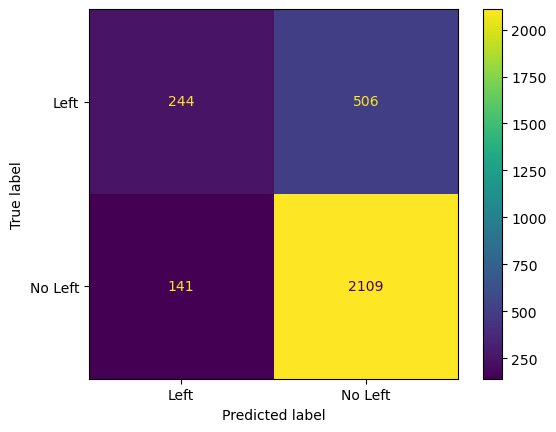

In [326]:
cm_plot.plot();

# Model is not great because FP is more - people leaving are not predicted correctly hence it is important

In [328]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [330]:
recall_score(y_df.actual, y_df.predicted)

0.3253333333333333

In [332]:
print(classification_report(y_df.actual, y_df.predicted))

# We only look at "1" value - here the recall is bad!

              precision    recall  f1-score   support

           0       0.81      0.94      0.87      2250
           1       0.63      0.33      0.43       750

    accuracy                           0.78      3000
   macro avg       0.72      0.63      0.65      3000
weighted avg       0.76      0.78      0.76      3000



## How to evaluate and compare models?

In [341]:
y_pred_probs = logreg_v1.predict_proba(X_test)

In [343]:
y_pred_probs[0:5]

array([[0.90589786, 0.09410214],
       [0.90324745, 0.09675255],
       [0.53545203, 0.46454797],
       [0.78228203, 0.21771797],
       [0.19334954, 0.80665046]])

In [345]:
y_pred_probs[:, 1]

array([0.09410214, 0.09675255, 0.46454797, ..., 0.07815918, 0.02660852,
       0.0297206 ])

In [347]:
y_df['pred_probs'] = y_pred_probs[:, 1]

In [349]:
y_df.sample(10, random_state=20)

,actual,predicted,pred_probs
310,1,1,0.603581
14670,1,0,0.354209
1322,1,0,0.200255
3314,0,0,0.091205
11348,0,0,0.389742
12630,1,1,0.689447
7293,0,0,0.033810
13600,0,0,0.241715
4038,0,0,0.049802
1499,1,0,0.434709


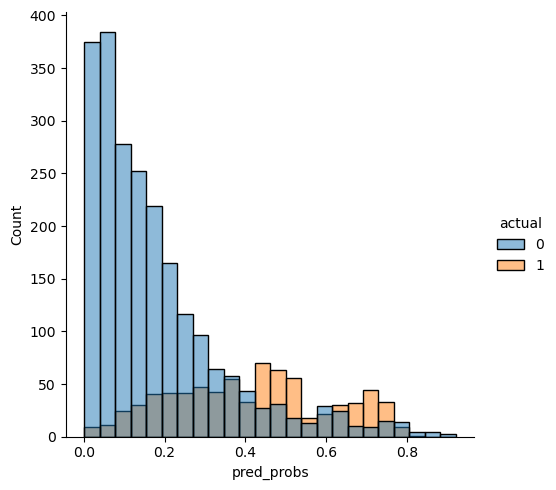

In [351]:
sn.displot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');

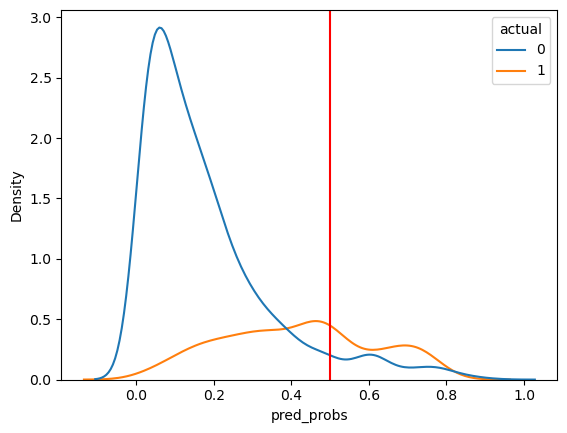

In [353]:
sn.kdeplot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');
plt.axvline(x = 0.5, color = 'r', label = 'cut off');

In [356]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [358]:
roc_auc_score(y_df.actual, y_df.pred_probs)

0.8346820740740741

###  Exercise:

- Build a logistic regression model between average_montly_hours and left
- Predict probability for different values of average_montly_hours from 50 hours to 400 hours with 10 hours of step
- Plot the logistic function

In [115]:
X = hr_df[['average_montly_hours']]
y = hr_df.left

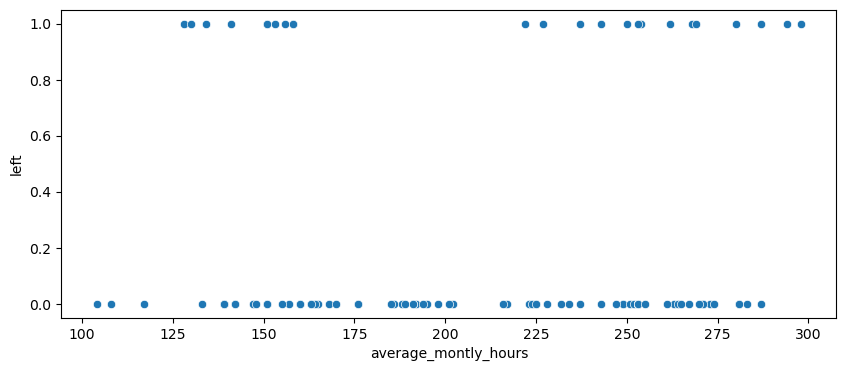

In [117]:
plt.figure(figsize=(10, 4))
sn.scatterplot(data = hr_df.sample(100, random_state = 78),
               x = 'average_montly_hours',
               y = 'left');

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [119]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split( X, y, 
                                                    test_size = 0.2, random_state = 100 )

In [123]:
#Check shape of Xtrain and Xtest
X_train.shape

(11999, 1)

In [125]:
X_test.shape

(3000, 1)

### Build Logistic Regression Model

In [128]:
from sklearn.linear_model import LogisticRegression

In [130]:
logreg_v1 = LogisticRegression(random_state=100)

In [132]:
logreg_v1.fit( X_train, y_train )

LogisticRegression(random_state=100)

### Finding Parameters

In [135]:
logreg_v1.intercept_

array([-1.89537826])

In [137]:
logreg_v1.coef_

array([[0.00351697]])

**Note:** What is the meaning of negative coefficient here?

### Probability of leaving at different Satisfaction Scores

- Create a list satisfaction scores from 0.0 to 1.0

In [154]:
sl_list = np.arange(50, 401, 10)

In [156]:
sl_list

array([ 50,  60,  70,  80,  90, 100, 110, 120, 130, 140, 150, 160, 170,
       180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300,
       310, 320, 330, 340, 350, 360, 370, 380, 390, 400])

In [158]:
beta_0 = logreg_v1.intercept_[0]
beta_1 = logreg_v1.coef_[0][0]

In [160]:
beta_0, beta_1

(-1.895378259128909, 0.003516972669478154)

- Calculate the probability values based on the logistic function

In [163]:
sl_probs = [(1.0 / (1.0 + np.exp(-(beta_0+beta_1*x)))) for x in sl_list]

In [165]:
sl_probs_df = pd.DataFrame({'SL': sl_list, 'Prob_Left': sl_probs })

In [167]:
sl_probs_df

,SL,Prob_Left
0,50,0.151932
1,60,0.156519
2,70,0.161218
3,80,0.166031
4,90,0.170958
5,100,0.176001
6,110,0.181160
7,120,0.186435
8,130,0.191829
9,140,0.197340


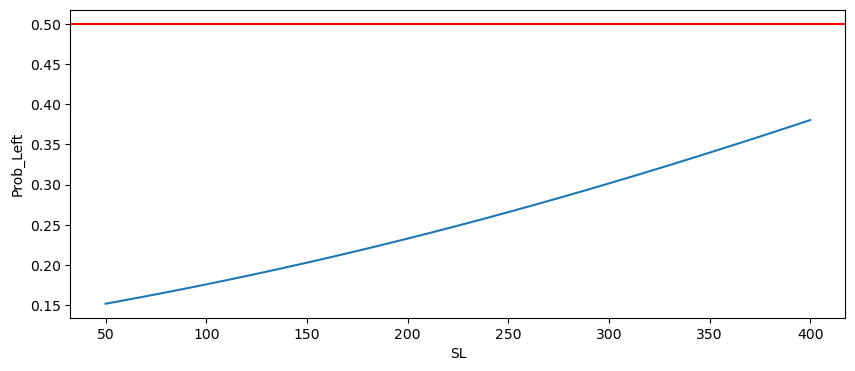

In [172]:
plt.figure(figsize=(10, 4))
sn.lineplot(data=sl_probs_df, x="SL", y="Prob_Left");
plt.axhline(y=0.5, color = 'r');

### Predicting on Test Data

In [174]:
y_pred = logreg_v1.predict(X_test)

In [176]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [178]:
y_df.sample(10, random_state=20)

,actual,predicted
310,1,0
14670,1,0
1322,1,0
3314,0,0
11348,0,0
12630,1,0
7293,0,0
13600,0,0
4038,0,0
1499,1,0


### Measuring Accuracy

In [180]:
from sklearn.metrics import accuracy_score

In [182]:
accuracy_score(y_test, y_pred)

0.75